# Comparison with CosmoPipe

In this notebook we are comparing the results with the [CosmoPipe](https://github.com/AngusWright/CosmoPipe) library. We are using the scripts [`get_weights_cosebi.py`](https://github.com/AngusWright/CosmoPipe/blob/master/scripts/get_weights_cosebis.py) and [`run_measure_cosebis_cats2stats.py`](https://github.com/AngusWright/CosmoPipe/blob/master/scripts/run_measure_cosebis_cats2stats.py) which we have axtracted to run it within our notebook.
To run this notebook, the installation of the full CosmoPipe library is probably not necessary, it is likely that the installion of [OneCovariance](https://github.com/rreischke/OneCovariance) is enough.
Other libraries are also required and installable with conda such as [CCL](https://github.com/LSSTDESC/CCL) used to generate shear-shear data vectors:
```bash
conda install -c conda-forge pyccl matplotlib tqdm scipy
```
The other libraries should be included with the installation of cosmo-numba.

In [1]:
import pyccl as ccl
import numpy as np
from tqdm import tqdm
from time import time

import matplotlib.pyplot as plt

In [2]:
from cosmo_numba.B_modes.cosebis import COSEBIS
from cosmo_numba.B_modes.cosebis_nb import get_Cell_cosebis_serial

In [3]:
import levin
from mpmath import mp
import mpmath
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema

## Cosmo model

In [4]:
def get_model(
    theta,
    z,
    nz,
    Omega_c,
    h,
    Omega_b,
    sig8,
    ns,
    B_amp,
    b_ia,
    l_min=None,
    l_max=None,
    ell=None,
):

    theta_deg = theta/60

    cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        n_s=ns,
        sigma8=sig8,

        transfer_function='boltzmann_camb',
        matter_power_spectrum='camb',
        extra_parameters={
            "camb": {
                "halofit_version": 'mead2016',
                "HMCode_A_baryon": B_amp,
                "kmax": 21,
                # We do this to avoid warnings in CAMB with (kmax < 5 or
                # 'kmax < 20 and z > 4') (set internally in ccl)
                # default: kmax=10
            }
        }
    )
    ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = True

    lens = ccl.WeakLensingTracer(
        cosmo,
        dndz=(z, nz),
        ia_bias=(z, np.ones_like(z)*b_ia),
        use_A_ia=True,
    )

    if ell is None:
        if l_min is None and l_max is None:
            l_min = 1
            l_max = 100_000
        l_bin = (l_max - l_min) + 1
        ell = np.logspace(np.log10(l_min), np.log10(l_max), l_bin)
    cl = ccl.angular_cl(cosmo, lens, lens, ell)

    xip_fit = ccl.correlation(
        cosmo,
        ell=ell,
        C_ell=cl,
        theta=theta_deg,
        type='GG+',
        method='fftlog',
    )
    xim_fit = ccl.correlation(
        cosmo,
        ell=ell,
        C_ell=cl,
        theta=theta_deg,
        type='GG-',
        method='fftlog'
    )

    return xip_fit, xim_fit, ell, cl

In [5]:
def smail_nz(z, z0, alpha, beta):
    """
    """
    return (z / z0) ** beta * np.exp(-(z / z0) ** alpha)

## Set parameters

In [6]:
tmin = 0.5
tmax = 250.

nbins = 10_000

In [7]:
# Planck cosmo 2018 | TT,TE,EE+lowE+lensing+BAO
h = 0.6766
Om = 0.3111
Ov = 0.6889
sig8 = 0.8102
ns = 0.9665
Ob_h2 = 0.02242
Ob = Ob_h2/h**2
Oc_h2 = 0.11933
Oc = Oc_h2/h**2
b_ia = 0.5
B_amp = 3.13

area = 14_300
shape_noise = 0.26
n_eff = 27

alpha_nz = 0.68
beta_nz = 2.
z0_nz = 0.13
z = np.linspace(0, 4, 256)
nz = smail_nz(z, z0_nz, alpha_nz, beta_nz)

## Get $\xi_{\pm}$ model

In [8]:
theta_ = np.logspace(np.log10(tmin), np.log10(tmax), nbins+1)
theta = np.mean([theta_[:-1], theta_[1:]], axis=0)
dtheta = np.diff(theta_)

In [9]:
xip_model, xim_model, ell, Cell = get_model(
    theta,
    z,
    nz,
    Oc,
    h,
    Ob,
    sig8,
    ns,
    B_amp,
    b_ia,
)

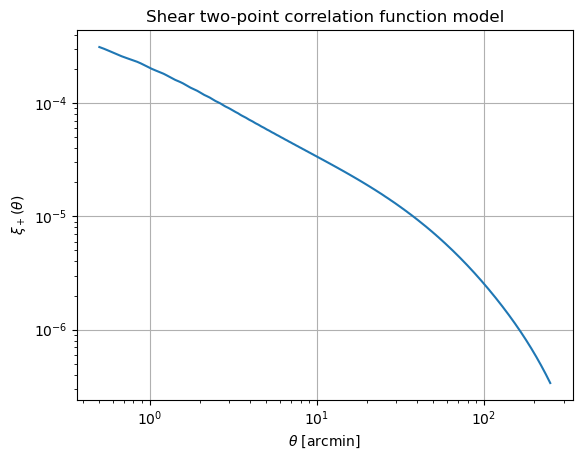

In [10]:
plt.plot(theta , xip_model)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi_+(\theta)$")
plt.title("Shear two-point correlation function model")
plt.grid()
plt.show()

### From CosmoPipe

In [11]:
ts = time()

num_cores = 16
Ntheta = 1_000
# tmin = 0.5
# tmax = 250.
ell_min = 1
ell_max = 100_000
Nell = 10_000
Nmax = 20
get_W_ell_as_well = True
remove_half = False
# convert_to_rad = False

# mpi.set_start_method("fork")
mp.dps = 160
arcmintorad = np.pi/180/60

#Convert to radians (needed for Wn!!)
tmin *= arcmintorad
tmax *= arcmintorad


#####################
zmax = mp.log(tmax/tmin)
# ell = np.geomspace(ell_min, ell_max, Nell)
ell = np.logspace(np.log10(ell_min), np.log10(ell_max), Nell)

### CASE FOR LN(THETA) EVENLY SPACED

##We here compute the c_nj
#compute the Js
def J(k,j,zmax):
    # using the lower gamma function returns an error
    #J = mp.gammainc(j+1,0,-k*zmax)
    # so instead we use the full gamma - gamma upper incomplete
    J = mp.gamma(j+1) - mp.gammainc(j+1,-k*zmax)
    k_power = mp.power(-k,j+1.)
    J = mp.fdiv(J,k_power)
    return J


# matrix of all the coefficient cs 
coeff_j = mp.matrix(Nmax+1,Nmax+2)
# add the constraint that c_n(n+1) is = 1
for i in range(Nmax+1):
    coeff_j[i,i+1] = mp.mpf(1.)


# determining c_10 and c_11
nn = 1
aa = [J(2,0,zmax),J(2,1,zmax)],[J(4,0,zmax),J(4,1,zmax)]
bb = [-J(2,nn+1,zmax),-J(4,nn+1,zmax)]
coeff_j_ini = mp.lu_solve(aa,bb)

coeff_j[1,0] = coeff_j_ini[0]
coeff_j[1,1] = coeff_j_ini[1]

# generalised for all N
# iteration over j up to Nmax solving a system of N+1 equation at each step
# to compute the next coefficient
# using the N-1 orthogonal equations Eq34 and the 2 equations 33

#we start from nn = 2 because we compute the coefficients for nn = 1 above
for nn in np.arange(2,Nmax+1):
    aa = mp.matrix(int(nn+1))
    bb = mp.matrix(int(nn+1),1)
    #orthogonality conditions: equations (34) 
    for m in np.arange(1,nn): 
        #doing a matrix multiplication (seems the easiest this way in mpmath)
        for j in range(0,nn+1):           
            for i in range(0,m+2): 
                aa[m-1,j] += J(1,i+j,zmax)*coeff_j[m,i] 
            
        for i in range(0,m+2): 
            bb[int(m-1)] -= J(1,i+nn+1,zmax)*coeff_j[m,i]

    #adding equations (33)
    for j in range(nn+1):
        aa[nn-1,j] = J(2,j,zmax) 
        aa[nn,j]   = J(4,j,zmax) 
        bb[int(nn-1)] = -J(2,nn+1,zmax)
        bb[int(nn)]   = -J(4,nn+1,zmax)

    temp_coeff = mp.lu_solve(aa,bb)
    coeff_j[nn,:len(temp_coeff)] = temp_coeff[:,0].T

#remove the n = 0 line - so now he n^th row is the n-1 mode.
coeff_j = coeff_j[1:,:]

##We here compute the normalization N_nm, solving equation (35)
Nn = []
for nn in np.arange(1,Nmax+1):
    temp_sum = mp.mpf(0)
    for i in range(nn+2):
        for j in range(nn+2):
            temp_sum += coeff_j[nn-1,i]*coeff_j[nn-1,j]*J(1,i+j,zmax)

    temp_Nn = (mp.expm1(zmax))/(temp_sum)
    #N_n chosen to be > 0.  
    temp_Nn = mp.sqrt(mp.fabs(temp_Nn))
    Nn.append(temp_Nn)


##We now want the root of the filter t_+n^log 
#the filter is: 
rn = []
for nn in range(1,Nmax+1):
    rn.append(mpmath.polyroots(coeff_j[nn-1,:nn+2][::-1],maxsteps=500,extraprec=100))
    #[::-1])



def tplus(tmin,tmax,n,norm,root,ntheta=10000):
    theta=np.logspace(np.log10(tmin),np.log10(tmax),ntheta)
    tplus=np.zeros((ntheta,2))
    tplus[:,0]=theta
    z=np.log(theta/tmin)
    result=1.
    for r in range(n+1):
        result*=(z-root[r])
    result*=norm
    tplus[:,1]=result
    return tplus

def tminus(tmin,tmax,n,norm,root,tp,ntheta=10000):
    tplus_func=interp1d(np.log(tp[:,0]/tmin),tp[:,1])
    rtminus = np.zeros_like(tp)
    rtminus[:,0] = tp[:,0]
    z=np.log(theta/tmin)
    rtminus[:,1]= tplus_func(z)
    lev = levin.Levin(0, 16, 32, 1e-8, 200, num_cores)
    wide_theta = np.linspace(theta[0]*0.999, theta[-1]*1.001,int(1e4))
    lev.init_w_ell(np.log(wide_theta/tmin), np.ones_like(wide_theta)[:,None])
    z=np.log(theta/tmin)
    for i_z, val_z in enumerate(z[1:]):
        y = np.linspace(z[0],val_z, 1000)
        integrand = tplus_func(y)*(np.exp(2*(y-val_z)) - 3*np.exp(4*(y-val_z)))
        limits_at_mode = np.array(y[argrelextrema(integrand, np.less)[0][:]])
        limits_at_mode_append = np.zeros(len(limits_at_mode) + 2)
        if len(limits_at_mode) != 0:
            limits_at_mode_append[1:-1] = limits_at_mode
        limits_at_mode_append[0] = y[0]
        limits_at_mode_append[-1] = y[-1]
        lev.init_integral(y,integrand[:,None],False,False)
        rtminus[i_z, 1] +=  4*lev.cquad_integrate_single_well(limits_at_mode_append,0)[0]
    return rtminus

def get_W_ell(theta, tp):
    lev_w = levin.Levin(0, 16, 32, 1e-8, 200, num_cores)
    lev_w.init_integral(theta,(theta*tp)[:,None]*np.ones(num_cores)[None,:],True,True)
    return lev_w.single_bessel_many_args(ell,0,theta[0],theta[-1])

Tp_log_cp = []
Tm_log_cp = []
Wn_log_cp = []
for nn in tqdm(range(1,Nmax+1)):
    n = nn-1
    tpn = tplus(tmin,tmax,nn,Nn[n],rn[n])
    theta = np.copy(tpn[:,0])
    tmn = tminus(tmin,tmax,1,Nn[n],rn[n], tpn)
    #Convert the radian back to arcmin 
    tpn[:,0] /= arcmintorad
    tmn[:,0] /= arcmintorad

    #If needed, get W_ell
    if get_W_ell_as_well:
        result_Well = get_W_ell(theta, tpn[:,1])

    Tp_log_cp.append(tpn)
    Tm_log_cp.append(tmn)
    if get_W_ell_as_well:
        Wn_log_cp.append(result_Well)

print("All done in:", time()-ts, "s")

100%|██████████| 20/20 [08:47<00:00, 26.39s/it]

All done in: 529.4596111774445 s


In [38]:
ts = time()
N_mode = 20
cosebis = COSEBIS(theta_min=tmin/arcmintorad, theta_max=tmax/arcmintorad, N_max=N_mode)
cosebis.compute_roots()

theta = np.copy(tpn[:,0])

Tp_log = cosebis.get_Tp_log(theta)
Tm_log = cosebis.get_Tm_log(theta)
Wn_log = cosebis.get_Wn_log(ell)

print("All done in:", time()-ts, "s")

All done in: 5.0671021938323975 s


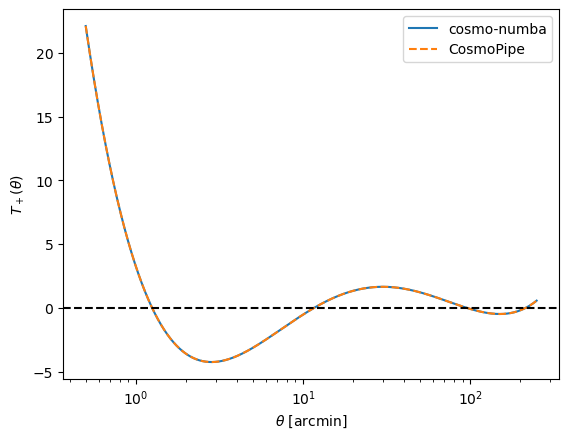

In [28]:
n_mode = 3
plt.plot(theta, Tp_log[n_mode-1], label="cosmo-numba")
plt.plot(theta, Tp_log_cp[n_mode-1][:, 1], "--", label="CosmoPipe")
plt.axhline(0, color="k", ls="--")
plt.xscale("log")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$T_+(\theta)$")
plt.legend()

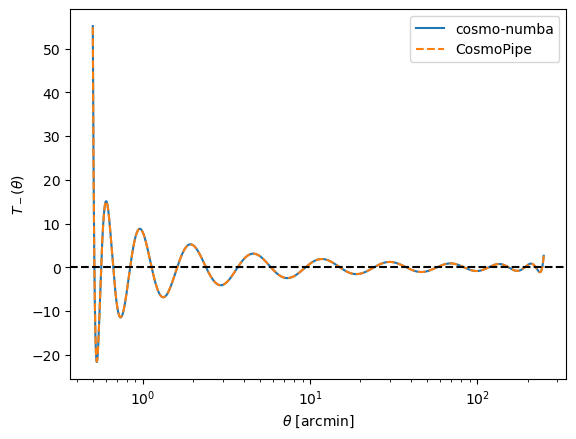

In [29]:
n_mode = 19
plt.plot(theta, Tm_log[n_mode-1], label="cosmo-numba")
plt.plot(theta, Tm_log_cp[n_mode-1][:, 1], "--", label="CosmoPipe")
plt.axhline(0, color="k", ls="--")
plt.xscale("log")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$T_-(\theta)$")
plt.legend()

Text(0, 0.5, '$W_{n}^{\\rm{log}}(\\ell)$')

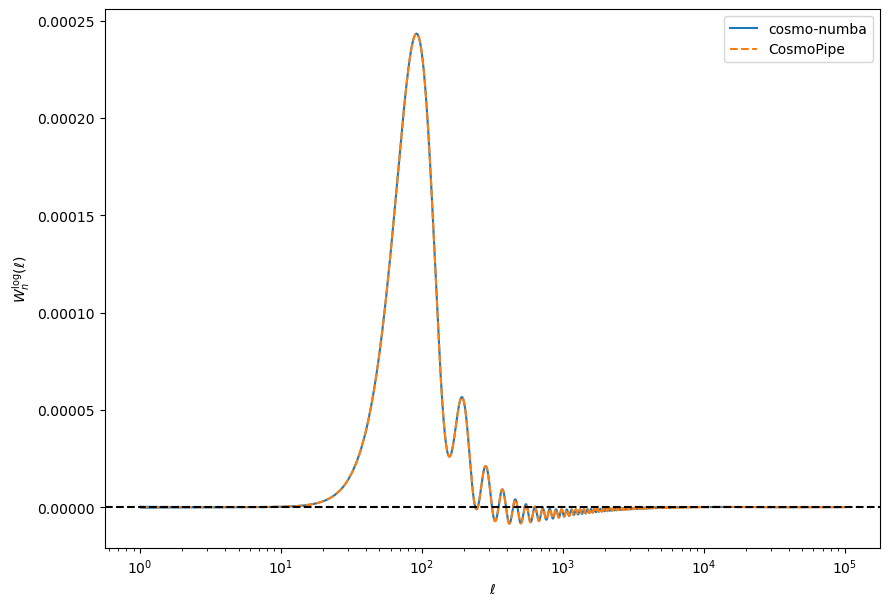

In [30]:
n = 1
plt.figure(figsize=(10, 7))
plt.plot(ell, Wn_log[n], label="cosmo-numba")
plt.plot(ell, Wn_log_cp[n], '--', label="CosmoPipe")
plt.axhline(0, ls='--', color="k")
plt.xscale("log")
# plt.ylim(-5e-5, 5e-5)
# plt.ylim(-5e-6, 5e-6)
# plt.ylim(-5e-7, 5e-7)
# plt.xlim(10_000, 300_000)
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$W_{n}^{\rm{log}}(\ell)$")

In [32]:
xip_model, xim_model, _, Cell = get_model(
    theta,
    z,
    nz,
    Oc,
    h,
    Ob,
    sig8,
    ns,
    B_amp,
    b_ia,
    ell=ell,
)

In [39]:
C_E, C_B = cosebis.cosebis_from_xipm(theta, xip_model, xim_model)

C_E_fftlog, C_B_fftlog = get_Cell_cosebis_serial(
    ell, Cell, np.zeros_like(Cell), Wn_log, N_mode,
)

C_E_levin, C_B_levin = get_Cell_cosebis_serial(
    ell, Cell, np.zeros_like(Cell), np.asarray(Wn_log_cp), N_mode,
)

In [34]:
thetamin = theta[0]
thetamax = theta[-1]
nbins_within_range=len(theta)
ix=np.linspace(0,nbins_within_range-1,nbins_within_range)
theta_mid=np.exp(np.log(thetamin)+(np.log(thetamax)-np.log(thetamin))/(nbins_within_range)*(ix+0.5))
# 
theta_edges=np.logspace(np.log10(thetamin),np.log10(thetamax),nbins_within_range+1)
# 
theta_low=theta_edges[0:-1]
theta_high=theta_edges[1::]
delta_theta=theta_high-theta_low
arcmin=180*60/np.pi

In [35]:
# %%timeit
En=np.zeros(Nmax)
Bn=np.zeros(Nmax)
for n in range(1, Nmax+1):
    #define Tplus and Tminus file names for this mode

    tp = Tp_log_cp[n-1]
    tm = Tm_log_cp[n-1]

    tp_func=interp1d(tp[:,0], tp[:,1])
    tm_func=interp1d(tm[:,0], tm[:,1])
    
    integ_plus=tp_func(theta_mid)*theta_mid*xip_model
    integ_minus=tm_func(theta_mid)*theta_mid*xim_model
    # 
    Integral_plus=sum(integ_plus*delta_theta)
    Integral_minus=sum(integ_minus*delta_theta)

    En[n-1]=0.5*(Integral_plus+Integral_minus)/arcmin/arcmin
    Bn[n-1]=0.5*(Integral_plus-Integral_minus)/arcmin/arcmin

Text(0, 0.5, '$E/B$-mode')

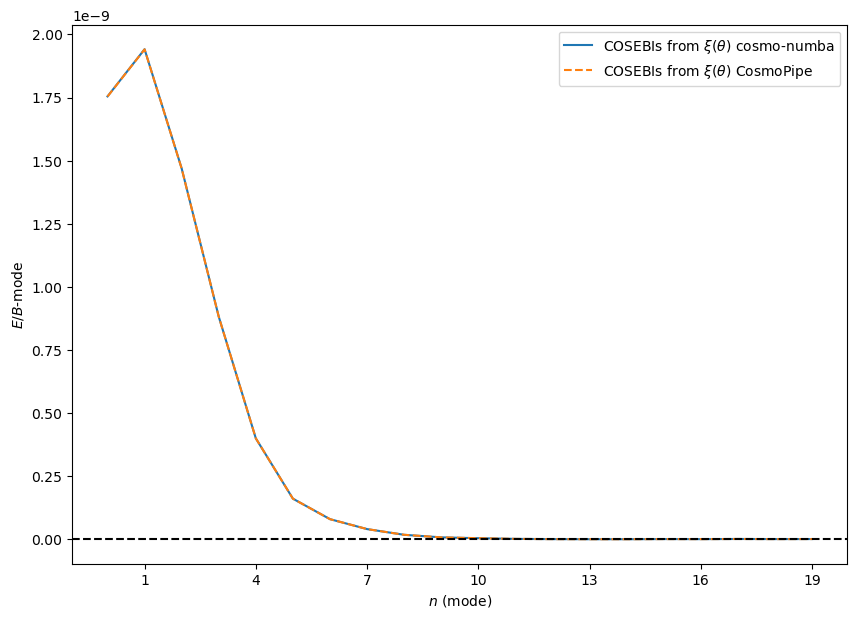

In [36]:
plt.figure(figsize=(10, 7))
plt.plot(C_E, label=r"COSEBIs from $\xi(\theta)$ cosmo-numba")
plt.plot(En, "--", label=r"COSEBIs from $\xi(\theta)$ CosmoPipe")
plt.axhline(0, ls='--', color="k")
plt.legend()
plt.xticks(range(1, 21)[::3], range(1, 21)[::3])
plt.legend()
plt.xlabel(r"$n$ (mode)")
plt.ylabel(r"$E/B$-mode")

Text(0, 0.5, '$E/B$-mode')

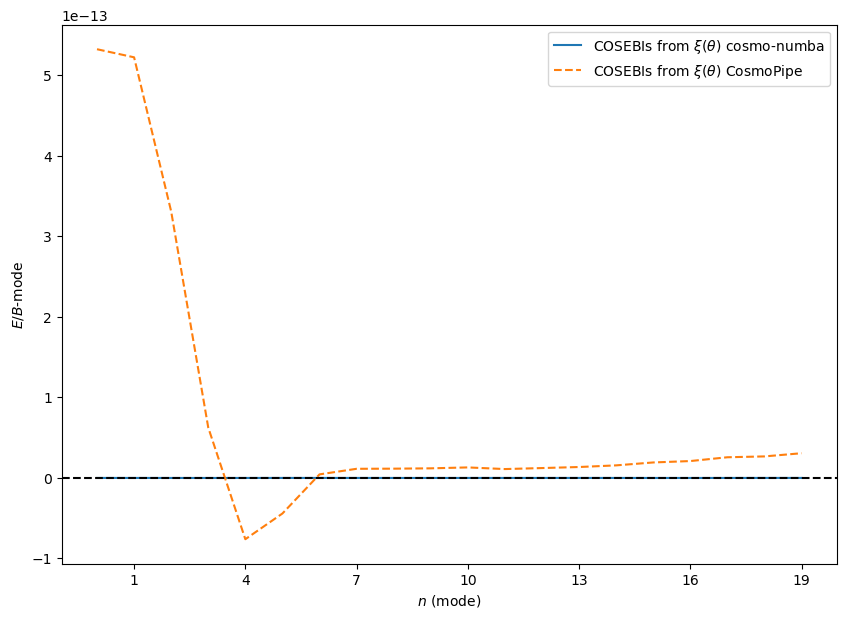

In [37]:
plt.figure(figsize=(10, 7))
plt.plot(C_B, label=r"COSEBIs from $\xi(\theta)$ cosmo-numba")
plt.plot(Bn, "--", label=r"COSEBIs from $\xi(\theta)$ CosmoPipe")
plt.axhline(0, ls='--', color="k")
plt.legend()
plt.xticks(range(1, 21)[::3], range(1, 21)[::3])
plt.legend()
# plt.ylim(-1e-12, 5.e-12)
plt.xlabel(r"$n$ (mode)")
plt.ylabel(r"$E/B$-mode")